In [1]:
import torch
from autoslo.nn.loss_functions import sensitive_q_error_loss
import matplotlib.pyplot as plt

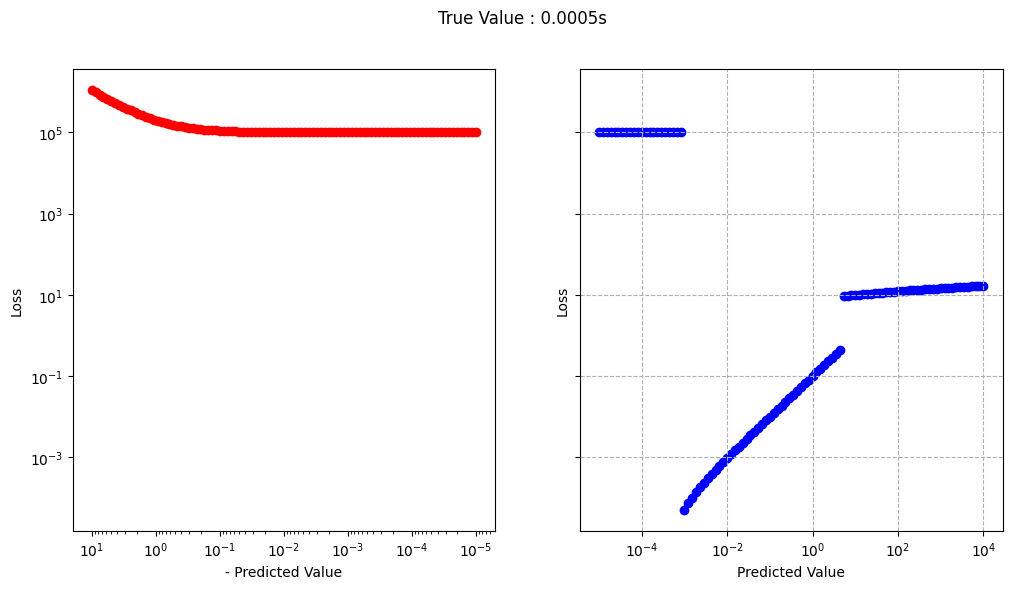

In [19]:
# For a true value of 10s, plot the loss (y axis) for different predicted values (x axis).
# Have the predicted valeus be between 10^-3 and 10^4 and make both axes log scale.

fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

val=0.0005

true_value = torch.tensor([val])

# Also plot a different subplot with negative predictions to show that the loss is very high there.
for pred in -torch.logspace(-5, 1, steps=100):
    pred_value = torch.tensor([pred])
    loss = sensitive_q_error_loss(input=pred_value, target=true_value)
    axs[0].scatter(-pred.item(), loss.item(), color='red')
# Invert x axis for negative predictions
axs[0].invert_xaxis()

for pred in torch.logspace(-5, 4, steps=100):
    pred_value = torch.tensor([pred])
    loss = sensitive_q_error_loss(input=pred_value, target=true_value)
    axs[1].scatter(pred.item(), loss.item(), color='blue')

axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlabel('- Predicted Value')
axs[0].set_ylabel('Loss')

axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_xlabel('Predicted Value')
axs[1].set_ylabel('Loss')
fig.suptitle(f'True Value: {val}s')
plt.grid(True, which="both", ls="--")
plt.show()


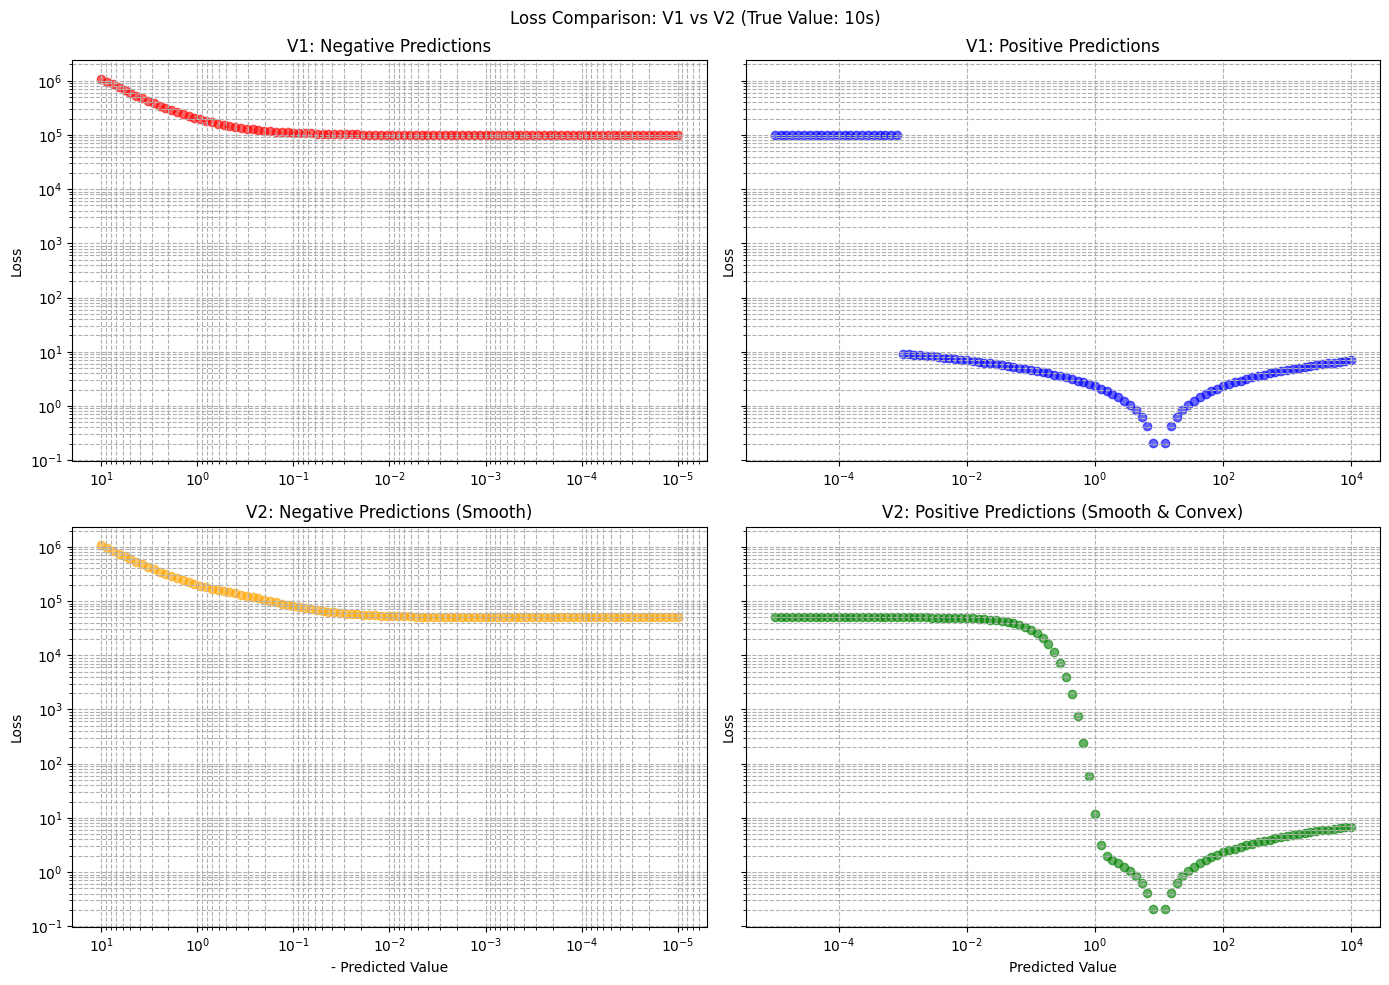


Sample loss values near boundaries:

V1 - Negative regime boundary (around min_val=0.001):
  input=0.0001: loss=100010.000000
  input=0.0005: loss=100050.000000
  input=0.0010: loss=9.210340
  input=0.0020: loss=8.517193

V2 - Negative regime boundary (around min_val=0.001):
  input=0.0001: loss=50235.230469
  input=0.0005: loss=50154.699219
  input=0.0010: loss=50054.554688
  input=0.0020: loss=49854.230469


In [33]:
# Compare v1 and v2 losses
from autoslo.nn.loss_functions import sensitive_q_error_loss

fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharey='row',)

val = 10
min_val = 1e-3
true_value = torch.tensor([val])

# V1: Negative predictions
for pred in -torch.logspace(-5, 1, steps=100):
    pred_value = torch.tensor([pred])
    loss_v1 = sensitive_q_error_loss(input=pred_value, target=true_value, version=1, min_val=min_val)
    axs[0, 0].scatter(-pred.item(), loss_v1.item(), color='red', alpha=0.6)

axs[0, 0].invert_xaxis()
axs[0, 0].set_xscale('log')
axs[0, 0].set_yscale('log')
axs[0, 0].set_ylabel('Loss')
axs[0, 0].set_title('V1: Negative Predictions')
axs[0, 0].grid(True, which="both", ls="--")

# V2: Negative predictions
for pred in -torch.logspace(-5, 1, steps=100):
    pred_value = torch.tensor([pred])
    loss_v2 = sensitive_q_error_loss(input=pred_value, target=true_value, version=2, min_val=min_val)
    axs[1, 0].scatter(-pred.item(), loss_v2.item(), color='orange', alpha=0.6)

axs[1, 0].invert_xaxis()
axs[1, 0].set_xscale('log')
axs[1, 0].set_yscale('log')
axs[1, 0].set_xlabel('- Predicted Value')
axs[1, 0].set_ylabel('Loss')
axs[1, 0].set_title('V2: Negative Predictions (Smooth)')
axs[1, 0].grid(True, which="both", ls="--")

# V1: Positive predictions
for pred in torch.logspace(-5, 4, steps=100):
    pred_value = torch.tensor([pred])
    loss_v1 = sensitive_q_error_loss(input=pred_value, target=true_value, version=1, min_val=min_val)
    axs[0, 1].scatter(pred.item(), loss_v1.item(), color='blue', alpha=0.6)

axs[0, 1].set_xscale('log')
axs[0, 1].set_yscale('log')
axs[0, 1].set_ylabel('Loss')
axs[0, 1].set_title('V1: Positive Predictions')
axs[0, 1].grid(True, which="both", ls="--")

# V2: Positive predictions
for pred in torch.logspace(-5, 4, steps=100):
    pred_value = torch.tensor([pred])
    loss_v2 = sensitive_q_error_loss(input=pred_value, target=true_value, version=2, min_val=min_val)
    axs[1, 1].scatter(pred.item(), loss_v2.item(), color='green', alpha=0.6)

axs[1, 1].set_xscale('log')
axs[1, 1].set_yscale('log')
axs[1, 1].set_xlabel('Predicted Value')
axs[1, 1].set_ylabel('Loss')
axs[1, 1].set_title('V2: Positive Predictions (Smooth & Convex)')
axs[1, 1].grid(True, which="both", ls="--")

fig.suptitle(f'Loss Comparison: V1 vs V2 (True Value: {val}s)')
plt.tight_layout()
plt.show()

# Print some sample loss values to verify smoothness
print("\nSample loss values near boundaries:")
print("\nV1 - Negative regime boundary (around min_val=0.001):")
for pred_val in [0.0001, 0.0005, 0.001, 0.002]:
    loss = sensitive_q_error_loss(torch.tensor([pred_val]), true_value, version=1, min_val=min_val)
    print(f"  input={pred_val:.4f}: loss={loss.item():.6f}")

print("\nV2 - Negative regime boundary (around min_val=0.001):")
for pred_val in [0.0001, 0.0005, 0.001, 0.002]:
    loss = sensitive_q_error_loss(torch.tensor([pred_val]), true_value, version=2, min_val=min_val)
    print(f"  input={pred_val:.4f}: loss={loss.item():.6f}")
